# Challenge — Red neuronal con Keras 3
### Universidad EAFIT | SI3003 — Introducción a la Inteligencia Artificial

---

## Objetivo

En clase construimos una red neuronal para clasificación de imágenes usando **Keras 3**.

En este ejercicio aplicarás **la misma receta** sobre un dataset diferente: **CIFAR-10 convertido a escala de grises**.

No necesitas diseñar un pipeline nuevo. La descarga, conversión a escala de grises y visualización están resueltas. Tu trabajo es completar únicamente las etapas de Keras que vimos en clase:

```text
Datos → Normalización → Modelo → Loss + Optimizer → fit() → evaluate() → Predicción
```

Las celdas marcadas con `# TODO` son las que debes completar.


---
## 0. Librerías


In [1]:
# Importamos Keras (API de alto nivel), sus capas, NumPy para arreglos y Matplotlib para graficar.
import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Fijamos la semilla para que los pesos iniciales y el barajado sean iguales en cada ejecución.
SEED = 42
keras.utils.set_random_seed(SEED)

# Mostramos la versión y el backend (motor de cálculo) que Keras está usando.
print(f"Keras version : {keras.__version__}")
print(f"Backend       : {keras.backend.backend()}")


Keras version : 3.15.1
Backend       : tensorflow


---
# 1. Dataset: CIFAR-10

CIFAR-10 contiene 50,000 imágenes de entrenamiento y 10,000 de prueba. Las imágenes originales son de **32×32×3** y pertenecen a 10 categorías:

`airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck`.


In [2]:
# Esta parte está resuelta.
# Keras descarga CIFAR-10 ya separado en entrenamiento (50.000) y prueba (10.000).
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Las etiquetas vienen con forma (N, 1); squeeze las deja como vector (N,) para indexarlas fácil.
y_train = y_train.squeeze()
y_test = y_test.squeeze()

# Nombres de las clases en el mismo orden que sus etiquetas numéricas (0 a 9).
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Verificamos las formas: 32x32 píxeles con 3 canales de color (RGB).
print("X_train original:", X_train.shape)
print("X_test original :", X_test.shape)
print("y_train         :", y_train.shape)


X_train original: (50000, 32, 32, 3)
X_test original : (10000, 32, 32, 3)
y_train         : (50000,)


## 1.1 RGB → escala de grises

Usaremos la transformación:

$$Gray = 0.299R + 0.587G + 0.114B$$

Esta parte está resuelta porque el objetivo del ejercicio es practicar Keras.


In [3]:
# Combinamos los canales R, G y B con pesos que imitan la sensibilidad del ojo humano (el verde pesa más).
# El resultado pierde el eje de color: cada imagen queda de 32x32.
X_train = (
    0.299 * X_train[..., 0] +
    0.587 * X_train[..., 1] +
    0.114 * X_train[..., 2]
)

# Aplicamos exactamente la misma conversión al conjunto de prueba.
X_test = (
    0.299 * X_test[..., 0] +
    0.587 * X_test[..., 1] +
    0.114 * X_test[..., 2]
)

print("X_train grayscale:", X_train.shape)
print("X_test grayscale :", X_test.shape)


X_train grayscale: (50000, 32, 32)
X_test grayscale : (10000, 32, 32)


### Pregunta 1

Después de convertir las imágenes a escala de grises, cada imagen tiene tamaño `32×32`.

¿Cuántos valores tendrá cada imagen después de aplicar `Flatten()`?

**Respuesta:**



**Respuesta:** 1024 valores. `Flatten()` toma la imagen de 32×32 y la estira en una sola fila, así que
multiplica las dos dimensiones: 32 × 32 = 1024. Es un solo número por píxel porque ya convertimos a
escala de grises; si siguiera en color serían 32 × 32 × 3 = 3072.

## 1.2 Normalización

Los valores de los píxeles están entre 0 y 255. Completa el código para llevarlos al rango `[0,1]`.


In [4]:
# TODO 1 — Normalización
# Dividimos entre 255 (el valor máximo de un píxel) para dejar todo entre 0 y 1.
# Con valores pequeños y en la misma escala, el entrenamiento es más estable y converge más rápido.
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

# Comprobamos que el mínimo sea 0 y el máximo 1.
print(X_train.min(), X_train.max())

0.0 1.0


In [5]:
# Validación TODO 1
# Revisamos que el tipo sea float32 y que los valores queden dentro de [0, 1].
assert X_train.dtype == np.float32
assert X_test.dtype == np.float32
assert X_train.min() >= 0.0
assert X_train.max() <= 1.0
print("✓ Datos normalizados correctamente")


✓ Datos normalizados correctamente


## 1.3 Visualización

Esta parte está resuelta.


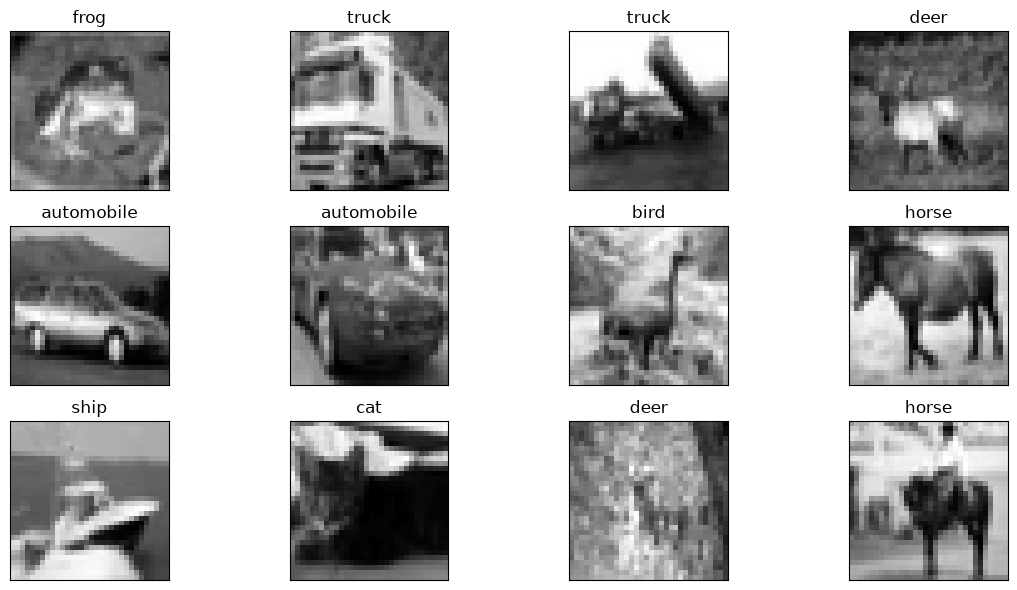

In [6]:
# Mostramos 12 imágenes de entrenamiento en una cuadrícula de 3x4 con su clase como título.
plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


---
# 2. Construir la red neuronal

Construiremos la misma arquitectura conceptual vista en clase:

```text
Imagen 32×32
   ↓
Flatten
   ↓
1024 valores
   ↓
Dense(128)
   ↓
ReLU
   ↓
Dense(10)
   ↓
Logits
```

> La última capa **no** debe tener Softmax. Trabajaremos con logits.


In [7]:
# TODO 2 — Completa la arquitectura
model = keras.Sequential([
    # Le decimos a la red que cada entrada es una imagen de 32x32.
    keras.Input(shape=(32, 32)),
    # Flatten va antes de Dense porque Dense solo recibe vectores: estira la imagen a 1024 valores.
    layers.Flatten(),
    # Capa oculta de 128 neuronas; ReLU aporta la no linealidad para aprender patrones complejos.
    layers.Dense(128, activation="relu"),
    # Una neurona por clase y sin activación: la salida son logits (puntajes crudos), no probabilidades.
    layers.Dense(10)
])

# Resumen de capas, formas de salida y número de parámetros entrenables.
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,490 (517.54 KB)

 Trainable params: 132,490 (517.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Validación TODO 2
# Parámetros esperados = pesos + sesgos de cada Dense: (1024*128 + 128) + (128*10 + 10) = 132.170.
expected_params = (1024 * 128 + 128) + (128 * 10 + 10)
assert model.count_params() == expected_params
print(f"✓ Arquitectura correcta: {model.count_params():,} parámetros")


✓ Arquitectura correcta: 132,490 parámetros


### Preguntas

**2.** ¿Por qué necesitamos `Flatten()` antes de la primera capa `Dense`?

**Respuesta:**


**3.** ¿Por qué la última capa tiene 10 neuronas?

**Respuesta:**


**4.** ¿Qué función cumple `ReLU`?

**Respuesta:**



**2.** Porque `Dense` (capa donde cada neurona se conecta con todas las entradas) solo acepta un vector
plano, no una matriz. La imagen llega como 32×32 y `Flatten()` la convierte en una lista de 1024 números.

**3.** Porque CIFAR-10 tiene 10 clases y la red produce un valor por clase. Cada neurona de salida
entrega el puntaje de una clase, y la predicción es la de mayor puntaje.

**4.** `ReLU` es la función que convierte en 0 todo valor negativo y deja igual los positivos. Aporta
**no linealidad**: sin ella, apilar capas `Dense` daría lo mismo que una sola capa, y la red no podría
aprender relaciones complejas.

---
# 3. Configurar el entrenamiento

Usaremos:

- `Adam`
- `SparseCategoricalCrossentropy`
- `accuracy`

Como la red produce logits, la pérdida debe configurarse con `from_logits=True`.


In [9]:
# Tasa de aprendizaje: qué tan grande es cada paso al ajustar los pesos.
lr_rate = 0.001

# TODO 3 — Configura el entrenamiento
model.compile(
    # Adam ajusta el tamaño del paso de cada peso de forma automática; es el optimizador por defecto más usado.
    optimizer=keras.optimizers.Adam(learning_rate=lr_rate),
    # Sparse porque las etiquetas son enteros (0-9), no one-hot.
    # from_logits=True porque la última capa entrega logits; la pérdida aplica Softmax por dentro, de forma más estable.
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    # Además de la pérdida, reportamos el porcentaje de aciertos.
    metrics=["accuracy"]
)

### Pregunta 5

¿Por qué usamos `from_logits=True`?

**Respuesta:**



**Respuesta:** Porque la última capa `Dense(10)` no tiene activación, así que produce **logits**
(puntajes sin normalizar, que pueden ser negativos o mayores que 1) y no probabilidades. Con
`from_logits=True` le avisamos a la función de pérdida que ella misma debe aplicar el Softmax
internamente. Hacerlo así es más estable numéricamente que aplicar Softmax en la capa y luego calcular
el logaritmo por separado.

---
# 4. Entrenar el modelo

Usaremos 10 épocas y mini-batches de 64 ejemplos. Completa `fit()`.


In [10]:
# 10 pasadas completas por los datos, actualizando los pesos cada 64 imágenes.
epochs = 10
batch_size = 64

# TODO 4 — Entrenamiento
# validation_data mide el desempeño en datos que la red no usa para aprender, al final de cada epoch;
# así podemos detectar overfitting. shuffle=True baraja los datos en cada epoch para no aprender el orden.
history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    shuffle=True
)

Epoch 1/10


  1/782 ━━━━━━━━━━━━━━━━━━━━ 3:51 296ms/step - accuracy: 0.0938 - loss: 2.4658

 38/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1336 - loss: 2.2990    

 78/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1607 - loss: 2.2306

120/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1753 - loss: 2.1987

...

630/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3810 - loss: 1.7551

673/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3819 - loss: 1.7531

713/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3829 - loss: 1.7503

755/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3838 - loss: 1.7481

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3838 - loss: 1.7479 - val_accuracy: 0.3632 - val_loss: 1.7837


### Preguntas

**6.** ¿Qué representa una `epoch`?

**Respuesta:**


**7.** ¿Qué representa `batch_size=64`?

**Respuesta:**



**6.** Una `epoch` es una pasada completa por todas las imágenes de entrenamiento. Con 10 epochs, la red
recorre las 50.000 imágenes diez veces, ajustando sus pesos en cada recorrido.

**7.** `batch_size=64` significa que los pesos se actualizan cada 64 imágenes, no una por una ni con
todas a la vez. Cada actualización usa el promedio del error de ese grupo, lo que da un entrenamiento
más rápido y estable que ir de a una.

## 4.1 Curvas de aprendizaje

Esta parte está resuelta.


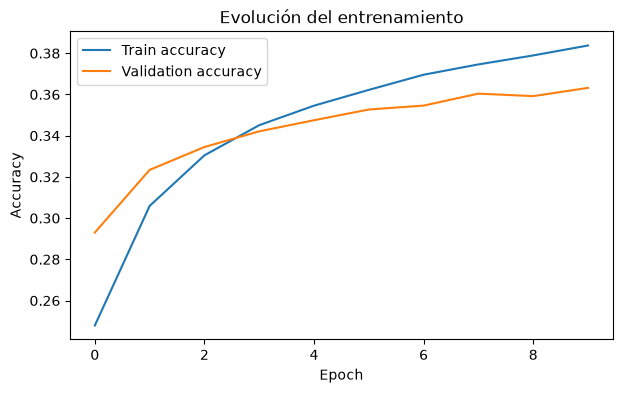

In [11]:
# Graficamos el accuracy de entrenamiento y de validación por epoch, guardados en history.
# Si se separan mucho, la red está memorizando en vez de generalizar.
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolución del entrenamiento")
plt.legend()
plt.show()


### Pregunta 8

Observa las dos curvas. ¿Hay evidencia de overfitting? Justifica brevemente.

**Respuesta:**



**Respuesta:** No hay overfitting fuerte (la red memorizando el entrenamiento en vez de generalizar), solo
una señal leve al final. En las primeras epochs la validación va incluso por encima del entrenamiento; las
curvas se cruzan hacia la epoch 4 y desde ahí el train sigue subiendo (hasta 38,4%) mientras la validación
avanza cada vez más lento (36,3%). La brecha final es de unos 2 puntos y la validación nunca baja, así que
el problema principal es que el modelo se queda corto (underfitting), no que memorice.

---
# 5. Evaluar el modelo

Completa `evaluate()`.


In [12]:
# TODO 5 — Evaluación
# Medimos pérdida y accuracy finales sobre el conjunto de prueba; verbose=0 evita la barra de progreso.
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    batch_size=batch_size,
    verbose=0
)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")
print(f"Accuracy (%)  : {test_accuracy * 100:.2f}%")

Test loss     : 1.7837
Test accuracy : 0.3632
Accuracy (%)  : 36.32%


### Pregunta 9

Compara este resultado con Fashion-MNIST, utilizado en clase.

¿CIFAR-10 en escala de grises parece más fácil o más difícil para esta red? Justifica usando el accuracy obtenido.

**Respuesta:**



**Respuesta:** Obtuvimos **36,32%** de accuracy en prueba, contra ~88% en Fashion-MNIST con la misma red.
CIFAR-10 en escala de grises es **mucho más difícil**: sus imágenes son fotografías reales con fondos,
ángulos y texturas variadas, mientras que Fashion-MNIST son prendas centradas sobre fondo negro. Además,
al pasar a grises perdimos el color, una pista útil para clases como *ship* o *frog*. Aun así, 36% está
muy por encima del 10% que daría adivinar al azar entre 10 clases.

---
# 6. Logits y Softmax

La salida de la red son 10 logits. Para interpretarlos como probabilidades necesitamos Softmax.


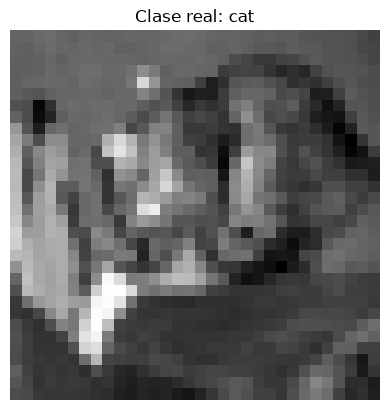

Logits:
[[ 0.98373634 -1.4904957   1.5513763   0.27764577  1.1497008   0.23951319
   0.4420262   0.45989344 -0.2526797  -1.912174  ]]


In [13]:
# Tomamos la primera imagen de prueba y mostramos su clase real.
index = 0
image = X_test[index]
true_class = y_test[index]

plt.imshow(image, cmap="gray")
plt.title(f"Clase real: {class_names[true_class]}")
plt.axis("off")
plt.show()

# La red espera un lote de imágenes, así que agregamos una dimensión: (32, 32) -> (1, 32, 32).
image_batch = np.expand_dims(image, axis=0)
# training=False indica que estamos prediciendo, no entrenando.
logits = model(image_batch, training=False)

# Los logits son 10 puntajes crudos: pueden ser negativos y no suman 1.
print("Logits:")
print(keras.ops.convert_to_numpy(logits))


In [14]:
# TODO 6 — Logits -> probabilidades
# Softmax convierte los logits en probabilidades entre 0 y 1 que suman 1, para poder interpretarlas.
probabilities = keras.ops.softmax(logits)

# TODO 7 — Clase con mayor probabilidad
# argmax devuelve el índice de la clase con mayor probabilidad. Softmax no cambia el orden,
# pero aplicarlo antes nos deja leer qué tan segura está la red.
prediction = keras.ops.argmax(probabilities, axis=1)
prediction = int(keras.ops.convert_to_numpy(prediction)[0])

print("Clase real     :", class_names[true_class])
print("Clase predicha :", class_names[prediction])

Clase real     : cat
Clase predicha : bird


In [15]:
# Pasamos las probabilidades a NumPy y tomamos la única imagen del lote.
probabilities_np = keras.ops.convert_to_numpy(probabilities)[0]

# Imprimimos la probabilidad de cada clase y marcamos la predicha.
print("\nProbabilidades:")
for i, p in enumerate(probabilities_np):
    marker = " ← predicción" if i == prediction else ""
    print(f"{class_names[i]:12s}: {p:.4f}{marker}")

# Comprobamos que las probabilidades suman aproximadamente 1.
print("\nSuma:", probabilities_np.sum())



Probabilidades:
airplane    : 0.1534
automobile  : 0.0129
bird        : 0.2707 ← predicción
cat         : 0.0757
deer        : 0.1811
dog         : 0.0729
frog        : 0.0893
horse       : 0.0909
ship        : 0.0446
truck       : 0.0085

Suma: 1.0


### Pregunta 10

¿Por qué las probabilidades producidas por `Softmax` deben sumar aproximadamente 1?

**Respuesta:**



**Respuesta:** Porque Softmax divide cada valor exponenciado entre la suma de todos los valores
exponenciados. Al dividir cada término por ese mismo total, la suma de los diez resultados da 1 por
construcción. Eso es justo lo que permite leerlos como probabilidades: se reparte el 100% de la
confianza entre las 10 clases. En la práctica puede dar 0.9999999 por redondeo del computador.

---
# 7. Varias predicciones

Esta parte está resuelta. Observa especialmente los errores del modelo.


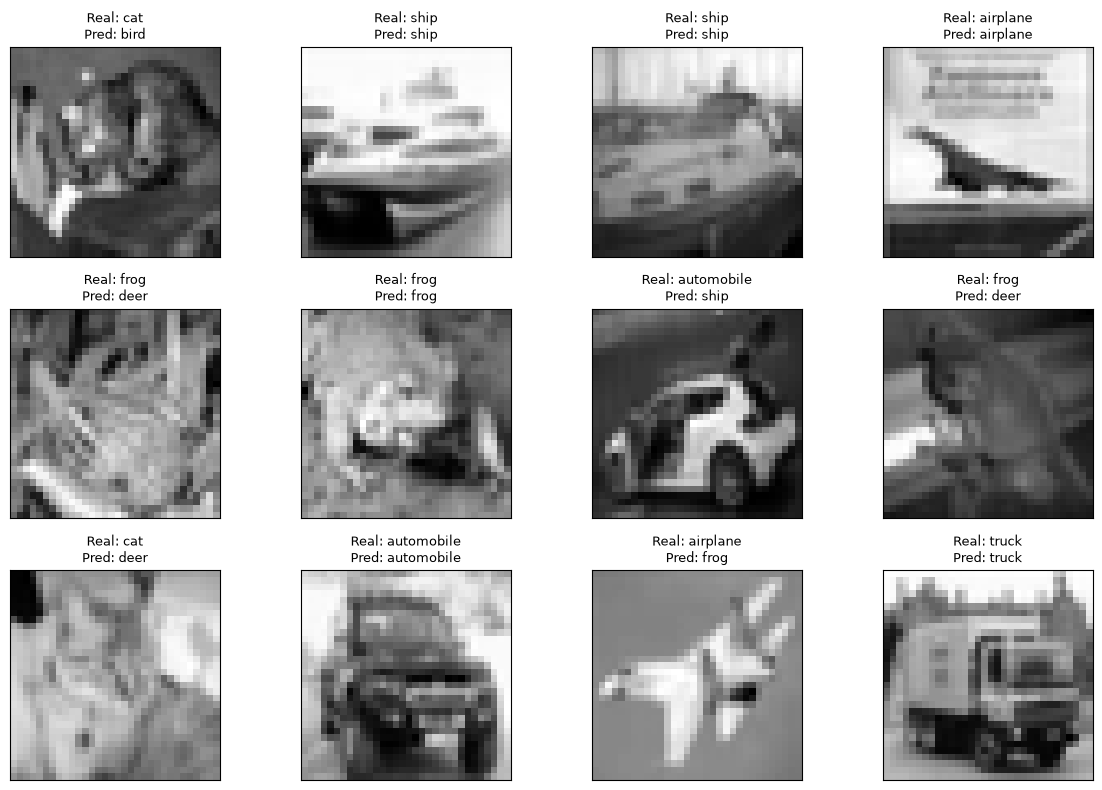

In [16]:
# Predecimos las primeras 12 imágenes de prueba de una sola vez.
# Aquí aplicamos argmax directo a los logits: Softmax no cambia cuál es el mayor.
n = 12
logits_batch = model(X_test[:n], training=False)
predictions = keras.ops.argmax(logits_batch, axis=1)
predictions = keras.ops.convert_to_numpy(predictions)

# Cuadrícula con la clase real y la predicha de cada imagen para ver en qué se equivoca la red.
plt.figure(figsize=(12, 8))
for i in range(n):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    real = class_names[y_test[i]]
    pred = class_names[predictions[i]]
    plt.title(f"Real: {real}\nPred: {pred}", fontsize=9)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


---
# 8. Reflexión final

### 1. ¿Cuál fue el accuracy final?

**Respuesta:**


### 2. ¿Qué clases parecen más difíciles de distinguir?

**Respuesta:**


### 3. Después de `Flatten()`, la imagen se convierte en un vector de 1024 valores. ¿Qué información importante sobre la imagen podría perderse al tratarla únicamente como un vector?

**Respuesta:**


### 4. ¿Qué tipo de arquitectura podría aprovechar mejor la estructura espacial de las imágenes?

**Respuesta:**

---

## Para pensar

Nuestro modelo hace:

```text
32×32 → Flatten → 1024 valores → Dense → ReLU → Dense(10)
```

Sin embargo, una imagen tiene **estructura espacial**: existen bordes, formas y patrones locales.

Este resultado nos deja preparada la siguiente pregunta del curso:

> **¿Cómo puede una red aprovechar directamente la estructura espacial de una imagen?**

La respuesta será: **Convolutional Neural Networks (CNNs)**.


## Respuestas — Reflexión final

**1.** El accuracy final en el conjunto de prueba fue **36,32%** (test loss de 1,7837). Es decir, la red
acierta un poco más de 1 de cada 3 imágenes, frente al 10% que se lograría adivinando al azar.

**2.** En la cuadrícula de la sección 7 la red acierta 6 de 12. Los errores se concentran en los animales:
*frog* se predijo como *deer* dos veces, *cat* como *deer* y como *bird*. También confundió *automobile*
con *ship* y *airplane* con *frog*. Sin color y con solo 32×32 píxeles, las siluetas de animales pequeños
y los fondos parecidos (agua, cielo, pasto) se vuelven difíciles de separar.

**3.** Se pierde la **estructura espacial**: cuáles píxeles eran vecinos, dónde había bordes y formas.
Para la red, el vector de 1024 números no tiene arriba ni abajo; si desordenáramos siempre igual todos
los píxeles, aprendería exactamente lo mismo. Tampoco reconoce un objeto si aparece desplazado.

**4.** Una **red convolucional (CNN)**, que aplica filtros pequeños sobre regiones vecinas de la imagen
y por eso sí aprovecha la cercanía entre píxeles y detecta patrones sin importar dónde aparezcan.